# SINDy on Real Treasury Yield Data

This notebook applies the from-scratch discrete-time SINDy implementation to real U.S. Treasury yield data.

We use the FRED series `DGS10`, the 10-Year Treasury Constant Maturity Rate.

The goal is not to build a perfect forecasting model, but to test whether SINDy selects a simple interpretable structure on real yield data.


In [4]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import io

import certifi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from src.discrete_sindy import fit_discrete_sindy, predict_discrete_sindy


## Load FRED data

`DGS10` is a daily FRED series for the 10-Year Treasury Constant Maturity Rate.

The values are quoted in percent. We later convert them into decimal form by dividing by 100.


In [5]:
series = "DGS10"
url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series}"

response = requests.get(url, timeout=30, verify=certifi.where())
response.raise_for_status()

data = pd.read_csv(io.StringIO(response.text))

print(data.head())
print(data.tail())


  observation_date  DGS10
0       1962-01-02   4.06
1       1962-01-03   4.03
2       1962-01-04   3.99
3       1962-01-05   4.02
4       1962-01-08   4.03
      observation_date  DGS10
16774       2026-04-20   4.26
16775       2026-04-21   4.30
16776       2026-04-22   4.30
16777       2026-04-23   4.34
16778       2026-04-24   4.31


## Clean data

FRED contains missing values for holidays and non-trading days. We convert the yield column to numeric, drop missing observations, and convert percent yields to decimals.


In [6]:
data["observation_date"] = pd.to_datetime(data["observation_date"])
data[series] = pd.to_numeric(data[series], errors="coerce")

data = data.dropna().reset_index(drop=True)

data["yield_percent"] = data[series]
data["yield_decimal"] = data["yield_percent"] / 100.0

print(data.head())
print(data.tail())
print("Number of observations:", len(data))


  observation_date  DGS10  yield_percent  yield_decimal
0       1962-01-02   4.06           4.06         0.0406
1       1962-01-03   4.03           4.03         0.0403
2       1962-01-04   3.99           3.99         0.0399
3       1962-01-05   4.02           4.02         0.0402
4       1962-01-08   4.03           4.03         0.0403
      observation_date  DGS10  yield_percent  yield_decimal
16058       2026-04-20   4.26           4.26         0.0426
16059       2026-04-21   4.30           4.30         0.0430
16060       2026-04-22   4.30           4.30         0.0430
16061       2026-04-23   4.34           4.34         0.0434
16062       2026-04-24   4.31           4.31         0.0431
Number of observations: 16063


## Plot yield series


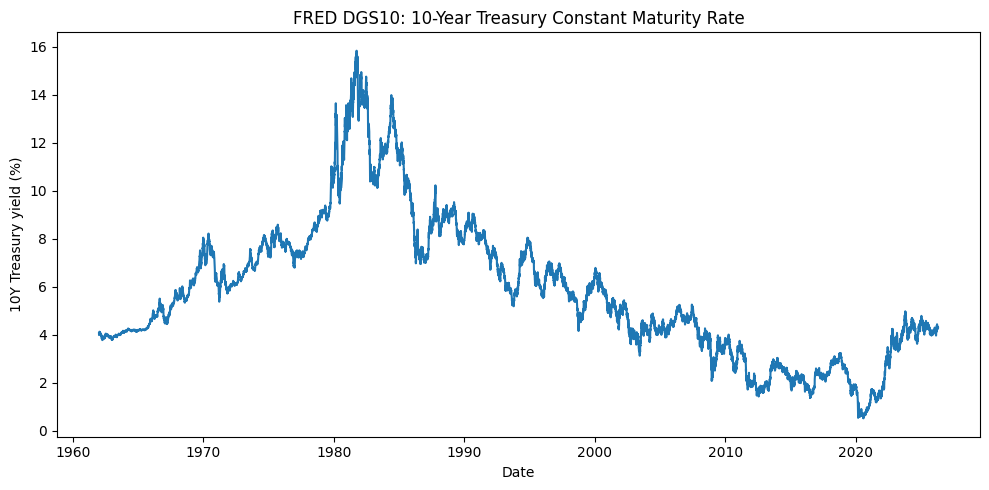

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(data["observation_date"], data["yield_percent"])
plt.xlabel("Date")
plt.ylabel("10Y Treasury yield (%)")
plt.title("FRED DGS10: 10-Year Treasury Constant Maturity Rate")
plt.tight_layout()
plt.show()


## Prepare SINDy data

We fit a simple discrete-time one-step model:

`y_next ≈ F(y)`

where `y` is the 10Y Treasury yield in decimal form.


In [8]:
y = data["yield_decimal"].to_numpy()

X = y[:-1].reshape(-1, 1)
Y = y[1:].reshape(-1, 1)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("First 5 X values:")
print(X[:5])
print("First 5 Y values:")
print(Y[:5])

X shape: (16062, 1)
Y shape: (16062, 1)
First 5 X values:
[[0.0406]
 [0.0403]
 [0.0399]
 [0.0402]
 [0.0403]]
First 5 Y values:
[[0.0403]
 [0.0399]
 [0.0402]
 [0.0403]
 [0.0405]]


## Fit linear discrete-time SINDy model

We first fit a simple linear one-step model:

`y_next ≈ c0 + c1 * y`

This is the real-data analogue of the discrete-time Vasicek experiment.




In [10]:
Xi_linear, names_linear = fit_discrete_sindy(

    X,

    Y,

    degree=1,

    threshold=0.000001,

    max_iter=10,

)

Y_hat_linear = predict_discrete_sindy(

    X,

    Xi_linear,

    degree=1,

)

mse_linear = np.mean((Y - Y_hat_linear) ** 2)

print("Feature names:", names_linear)

print("Xi:")

print(Xi_linear)

print("MSE:", mse_linear)

Feature names: ['1', 'x1']
Xi:
[[1.44974567e-05]
 [9.99753261e-01]]
MSE: 4.2028929392126807e-07



## Plot fitted one-step dynamics


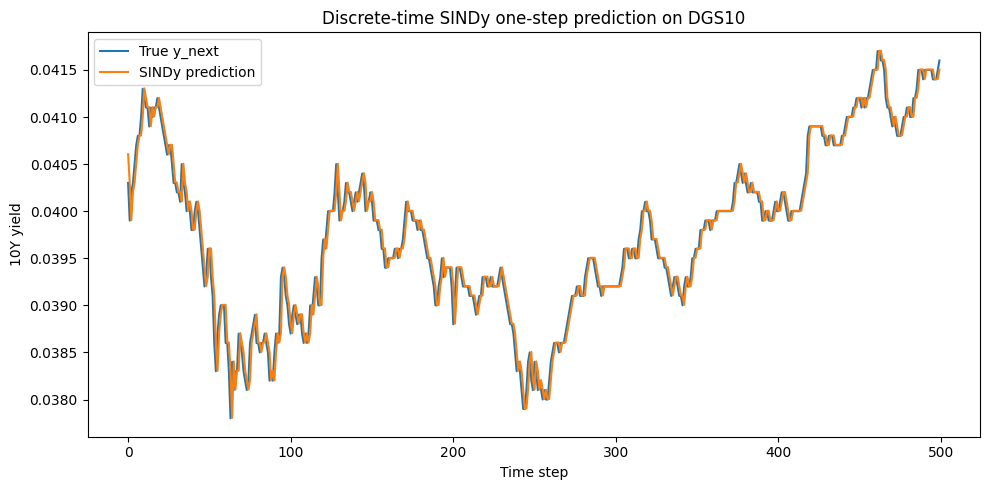

In [12]:
n_plot = 500

plt.figure(figsize=(10, 5))

plt.plot(Y[:n_plot], label="True y_next")

plt.plot(Y_hat_linear[:n_plot], label="SINDy prediction")

plt.xlabel("Time step")

plt.ylabel("10Y yield")

plt.title("Discrete-time SINDy one-step prediction on DGS10")

plt.legend()

plt.tight_layout()

plt.show()


## Interpretation

The linear SINDy model estimates a one-step relation of the form:

`y_next ≈ c0 + c1 * y`

If `c1` is close to 1, the yield process is highly persistent.

If `c1 < 1`, the fitted model has a weak mean-reverting structure.

The implied long-run mean of the linear model is:

`mean = c0 / (1 - c1)`

provided that `c1 < 1`.


## Implied long-run mean

For a linear one-step model

`y_next = c0 + c1 * y`

the fixed point is given by:

`y_bar = c0 / (1 - c1)`

provided that `c1 < 1`.

In [13]:
c0 = Xi_linear[0, 0]

c1 = Xi_linear[1, 0]

implied_mean = c0 / (1 - c1)

print("c0:", c0)

print("c1:", c1)

print("Implied long-run mean (decimal):", implied_mean)

print("Implied long-run mean (%):", implied_mean * 100)

c0: 1.4497456729415136e-05
c1: 0.9997532611276928
Implied long-run mean (decimal): 0.05875627376364718
Implied long-run mean (%): 5.875627376364718


## Fit quadratic discrete-time SINDy model

Next, we allow a quadratic term:

`y_next ≈ c0 + c1*y + c2*y^2`

This checks whether SINDy selects a more complex nonlinear structure on real yield data.

In [14]:
Xi_quad, names_quad = fit_discrete_sindy(

    X,

    Y,

    degree=2,

    threshold=0.000001,

    max_iter=10,

)

Y_hat_quad = predict_discrete_sindy(

    X,

    Xi_quad,

    degree=2,

)

mse_quad = np.mean((Y - Y_hat_quad) ** 2)

print("Feature names:", names_quad)

print("Xi:")

print(Xi_quad)

print("MSE:", mse_quad)

Feature names: ['1', 'x1', 'x1^2']
Xi:
[[ 1.32301488e-06]
 [ 1.00023341e+00]
 [-3.47458770e-03]]
MSE: 4.20272928658801e-07



## Compare linear vs quadratic model

In [15]:

print("Linear MSE:", mse_linear)

print("Quadratic MSE:", mse_quad)

print("Linear coefficients:")

print(Xi_linear)

print("Quadratic coefficients:")

print(Xi_quad)

Linear MSE: 4.2028929392126807e-07
Quadratic MSE: 4.20272928658801e-07
Linear coefficients:
[[1.44974567e-05]
 [9.99753261e-01]]
Quadratic coefficients:
[[ 1.32301488e-06]
 [ 1.00023341e+00]
 [-3.47458770e-03]]


## Train/test split

To avoid judging the model only in-sample, we split the time series into a training and a test part.

We fit SINDy on the training data and evaluate one-step predictions on the held-out test data.

In [16]:
split_idx = int(0.8 * len(X))

X_train = X[:split_idx]

Y_train = Y[:split_idx]

X_test = X[split_idx:]

Y_test = Y[split_idx:]

print("Train samples:", len(X_train))

print("Test samples:", len(X_test))

Train samples: 12849
Test samples: 3213


## Out-of-sample linear model

In [17]:
Xi_linear_oos, names_linear_oos = fit_discrete_sindy(

    X_train,

    Y_train,

    degree=1,

    threshold=0.000001,

    max_iter=10,

)

Y_test_hat_linear = predict_discrete_sindy(

    X_test,

    Xi_linear_oos,

    degree=1,

)

test_mse_linear = np.mean((Y_test - Y_test_hat_linear) ** 2)

print("Feature names:", names_linear_oos)

print("Xi:")

print(Xi_linear_oos)

print("Test MSE linear:", test_mse_linear)

Feature names: ['1', 'x1']
Xi:
[[1.44288499e-05]
 [9.99759327e-01]]
Test MSE linear: 2.7306785724469e-07


## Out-of-sample quadratic model


In [18]:
Xi_quad_oos, names_quad_oos = fit_discrete_sindy(

    X_train,

    Y_train,

    degree=2,

    threshold=0.000001,

    max_iter=10,

)

Y_test_hat_quad = predict_discrete_sindy(

    X_test,

    Xi_quad_oos,

    degree=2,

)

test_mse_quad = np.mean((Y_test - Y_test_hat_quad) ** 2)

print("Feature names:", names_quad_oos)

print("Xi:")

print(Xi_quad_oos)

print("Test MSE quadratic:", test_mse_quad)

Feature names: ['1', 'x1', 'x1^2']
Xi:
[[-1.85769778e-05]
 [ 1.00076486e+00]
 [-6.54371223e-03]]
Test MSE quadratic: 2.73298743809107e-07


## Out-of-sample prediction comparison

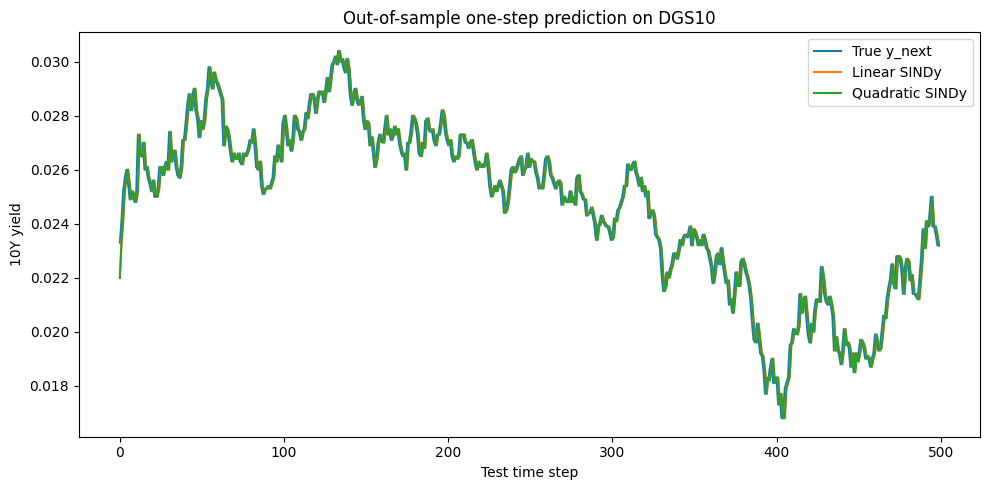

Test MSE linear: 2.7306785724469e-07
Test MSE quadratic: 2.73298743809107e-07


In [19]:
n_plot = 500

plt.figure(figsize=(10, 5))

plt.plot(Y_test[:n_plot], label="True y_next")

plt.plot(Y_test_hat_linear[:n_plot], label="Linear SINDy")

plt.plot(Y_test_hat_quad[:n_plot], label="Quadratic SINDy")

plt.xlabel("Test time step")

plt.ylabel("10Y yield")

plt.title("Out-of-sample one-step prediction on DGS10")

plt.legend()

plt.tight_layout()

plt.show()

print("Test MSE linear:", test_mse_linear)

print("Test MSE quadratic:", test_mse_quad)


## Real-data conclusion

The real DGS10 yield series is highly persistent at daily frequency.

The linear SINDy model estimates:

`y_next ≈ 0.0000144 + 0.999759 * y`

The coefficient on the current yield is very close to one, indicating near-random-walk behavior over one-day horizons.

Allowing a quadratic term improves the in-sample MSE only marginally, but performs slightly worse out-of-sample.

Therefore, the simpler linear model is preferred for this real-data experiment.

This contrasts with the synthetic Vasicek experiment, where the data-generating dynamics are known and SINDy can recover the mean-reverting structure much more cleanly.

The simulated Vasicek experiment confirms that the implementation can recover known mean-reverting dynamics when the data-generating process matches the model class.

On real DGS10 data, however, SINDy identifies a near-unit-root one-step dynamic rather than a clean Vasicek-type mean-reverting structure. This suggests that daily 10Y yield dynamics are dominated by persistence and regime-dependent behavior, and that a constant-parameter Vasicek model is too restrictive for this real-data setting.
